Import Libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Upload CSV Files

In [59]:
df = pd.read_csv('/content/house_price_dataset.csv')

show dataset

In [60]:
df

,Area_sqft,Bedrooms,Bathrooms,Age_years,Price
0,3119,1,1,23,10425321
1,1414,2,3,3,5651920
2,2733,1,2,1,8937742
3,1395,2,3,19,4737019
4,1314,5,4,7,5542124
...,...,...,...,...,...
795,2801,5,3,7,11078515
796,3836,2,2,9,14441638
797,1706,2,1,23,5511100
798,3375,5,4,27,13859329


Remove Uneccesary Columns

In [61]:
df.drop(columns=['Age_years'],inplace=True)
df.drop(columns=['Bathrooms'],inplace=True)

Show Top 5 Rows

In [62]:
df.head()

,Area_sqft,Bedrooms,Price
0,3119,1,10425321
1,1414,2,5651920
2,2733,1,8937742
3,1395,2,4737019
4,1314,5,5542124


Show Last 5 Rows

In [63]:
df.tail()

,Area_sqft,Bedrooms,Price
795,2801,5,11078515
796,3836,2,14441638
797,1706,2,5511100
798,3375,5,13859329
799,2824,1,9563196


Show Rows and Columns

In [64]:
df.shape

(800, 3)

Check Null Values

In [65]:
df.isnull().sum()

,0
Area_sqft,0
Bedrooms,0
Price,0


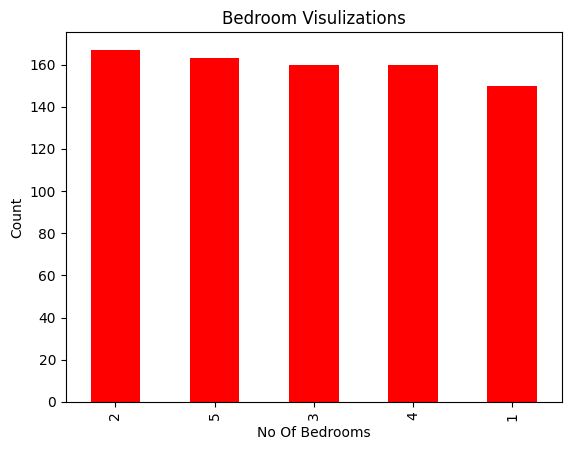

In [66]:
df['Bedrooms'].value_counts().plot(kind='bar',color='red')
plt.title('Bedroom Visulizations')
plt.xlabel('No Of Bedrooms')
plt.ylabel('Count')
plt.show()

Import Sklearn Library

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Feature Selection

In [68]:
X = df[['Area_sqft','Bedrooms']]
y = df['Price']

Training and Testing

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

Import Model

In [70]:
model = LinearRegression()

Fit The Model

In [71]:
model.fit(X_train,y_train)

LinearRegression()

Pred

In [72]:
y_pred = model.predict(X_test)

check r2_score and mean_squared_error

In [73]:
from sklearn.metrics import r2_score, mean_squared_error

In [74]:
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

In [75]:
print(f'The R2 score is: {r2 * 100:.2f}%')
print(f'The Mean_Squared_Error is: {mse * 100:.2f}')

The R2 score is: 97.55%
The Mean_Squared_Error is: 31928189562427.29


## Predict Price for New Data

In [80]:
user_input_area = int(input('Enter Area: '))
user_input_no_of_bedrooms = int(input('Enter no of Bedrooms: '))

new_house_data = pd.DataFrame({
    'Area_sqft': [user_input_area],
    'Bedrooms': [user_input_no_of_bedrooms]
})

predicted_price = model.predict(new_house_data)

print(f"Predicted price for a house with {user_input_area} sqft and {user_input_no_of_bedrooms} bedrooms: ${predicted_price[0]:,.2f}")

Enter Area: 1200
Enter no of Bedrooms: 2
Predicted price for a house with 1200 sqft and 2 bedrooms: $4,480,487.44
